exploring the made datasets - posts stats and commments

In [107]:
import pandas as pd

df=pd.read_csv("data\content_performance.csv")
comments=pd.read_csv("data\comments.csv")

print("exploring stats :")
print(df.head())
print(df.describe())
print(df.info())

print("exploring comments :")
print(comments.head())
print(comments.describe())

exploring stats :
   post_id          topic format  post_time  likes  shares  saves  comments  \
0        1     Friendship   Long    Morning   2970    1326   1422       235   
1        2     Loneliness   Long      Night   1469     559    320        89   
2        3     Loneliness   Long  Afternoon   1588     463    505        96   
3        4  Mental Health   Long    Evening   3048    1028    844       159   
4        5     Friendship   Long      Night   1985     905    974       131   

   retention_rate  
0            0.95  
1            0.64  
2            0.69  
3            0.95  
4            0.95  
         post_id        likes       shares        saves    comments  \
count  70.000000    70.000000    70.000000    70.000000   70.000000   
mean   35.500000  2526.000000   927.428571   915.657143  245.800000   
std    20.351085   875.801281   383.822104   379.043452  104.231153   
min     1.000000   853.000000   324.000000   320.000000   89.000000   
25%    18.250000  1907.750000   

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\91728\AppData\Local\Temp\ipykernel_60364\2547697348.py:3: SyntaxWarning: invalid escape sequence '\c'
  df=pd.read_csv("data\content_performance.csv")
C:\Users\91728\AppData\Local\Temp\ipykernel_60364\2547697348.py:4: SyntaxWarning: invalid escape sequence '\c'
  comments=pd.read_csv("data\comments.csv")


calculating virality coefficient of each reel/post using the formula "Virality Score = 0.2*(likes) + 0.4*(shares) + 0.3*(saves) + 0.1*(comments)", weights are assigned based on engagement pull of each action. 


In [108]:
df['virality_coeff'] = df['shares']*0.4 + df['saves']*0.3 + df['likes']*0.2 + df['comments']*0.1

In [109]:
df

,post_id,topic,format,post_time,likes,shares,saves,comments,retention_rate,virality_coeff
0,1,Friendship,Long,Morning,2970,1326,1422,235,0.95,1574.5
1,2,Loneliness,Long,Night,1469,559,320,89,0.64,622.3
2,3,Loneliness,Long,Afternoon,1588,463,505,96,0.69,663.9
3,4,Mental Health,Long,Evening,3048,1028,844,159,0.95,1289.9
4,5,Friendship,Long,Night,1985,905,974,131,0.95,1064.3
...,...,...,...,...,...,...,...,...,...,...
65,66,Career Stress,Short,Morning,3045,1580,1676,302,0.95,1774.0
66,67,Mental Health,Long,Evening,3769,1318,1537,503,0.95,1792.4
67,68,Friendship,Short,Evening,3001,1369,1310,222,0.95,1563.0
68,69,Dating,Long,Afternoon,3434,2158,987,376,0.95,1883.7


the scores are too high, lets normalize them by dividing each action with its max value
==> normalized score  = action_value/max_action_value

new formula = "Virality Score = 0.2*(likes)/max_likes + 0.4*(shares)max_shares + 0.3*(saves)max_shares + 0.1*(comments)max_comments
"

In [110]:
max_likes = df["likes"].max()
max_shares = df["shares"].max()
max_saves = df["saves"].max()
max_comments = df["comments"].max()

df['virality_coeff'] = 0.4*(df['shares']/max_shares) + 0.3*(df['saves']/max_saves) + 0.2*(df['likes']/max_likes) + 0.1*(df['comments']/max_comments)

In [111]:
df["virality_coeff"] = df["virality_coeff"].round(3)
df
df.to_csv("data/content_performance.csv", index=False)

Now its time to categorize the comments in comments.csv as relatable or neutral using TextBlob


In [112]:
!pip install textblob
!python -m textblob.download_corpora


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\91728\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [113]:
from textblob import TextBlob

idea is to loop through each comment in comments and check for words like "feel" , "me" , "accurate" . and flag them as relatable, otherwise neutral

In [114]:
keywords = ["feel" , "like" , "me" ,"accurate", "relatable", "needed" ,"describe" , "real" , "me core"]

def classify_comment(comment):
    cmt_lwr = comment.lower()
    if any(keyword in cmt_lwr for keyword in keywords):
        return "relatable"
    return "neutral"

In [115]:
comments["sentiments"] = comments["comment_text"].apply(classify_comment)
comments

,post_id,comment_text,sentiments
0,1,I'm crying this is so real,relatable
1,1,okay but why does this describe my life,relatable
2,1,okay but why does this describe my life,relatable
3,1,okay but why,neutral
4,1,okay but why,neutral
...,...,...,...
396,79,thanks for sharing,neutral
397,80,this is the most relatable thing I've ever seen,relatable
398,80,thanks for sharing,neutral
399,80,nobody talks about this enough,neutral


Time for A/B testing - by grouping the posts format and virality coefficient
we will use matplotlib for plotting graphs and charts


In [116]:
ab = df.groupby("format")["virality_coeff"].mean()
print(ab)

format
Long     0.431568
Short    0.482212
Name: virality_coeff, dtype: float64


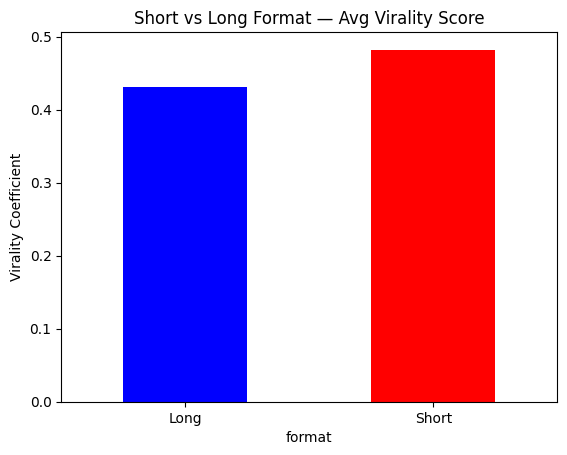

In [117]:
import matplotlib.pyplot as plt
ab.plot(kind="bar", color=["blue", "red"])
plt.title("Short vs Long Format — Avg Virality Score")
plt.ylabel("Virality Coefficient")
plt.xticks(rotation=0)
plt.savefig("charts/ab_test.png")
plt.show()

Now, we will write a function that will recommend us top three topics that are trending in current time, based on virality coefficient



In [118]:
top_topics = df.groupby("topic")["virality_coeff"].mean().sort_values(ascending=False)
print(top_topics.round(3))

print("\n TOP 3 RECOMMENDATIONS FOR NEXT WEEK : ")
for i, (topic, score) in enumerate(top_topics.head(3).items()):
    print(f"{i+1}. {topic} — avg virality: {score:.3f}")

topic
Dating              0.504
Friendship          0.476
Mental Health       0.466
Career Stress       0.463
Social Anxiety      0.441
Self Improvement    0.418
Loneliness          0.395
Name: virality_coeff, dtype: float64

 TOP 3 RECOMMENDATIONS FOR NEXT WEEK : 
1. Dating — avg virality: 0.504
2. Friendship — avg virality: 0.476
3. Mental Health — avg virality: 0.466


Creating charts for data visualization

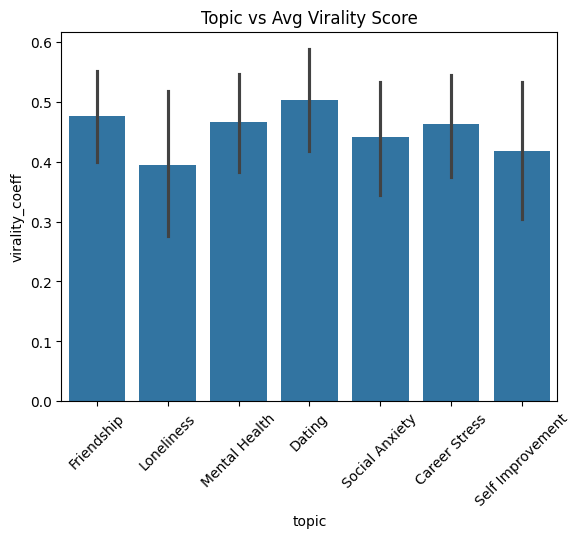

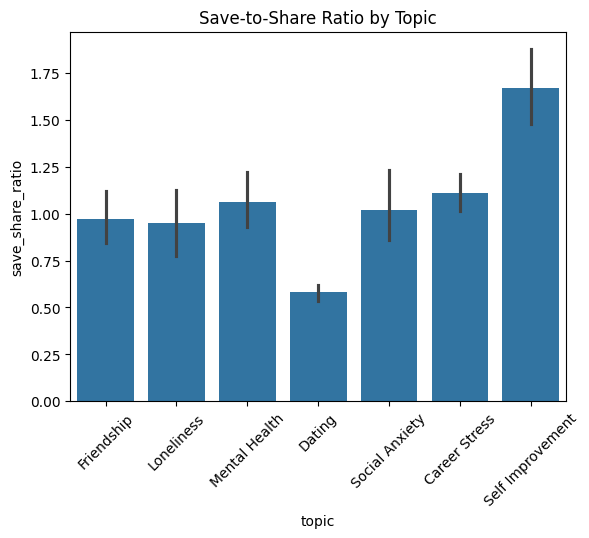

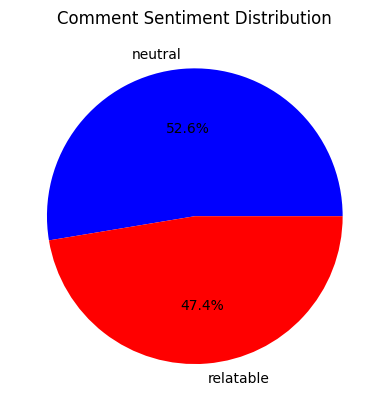

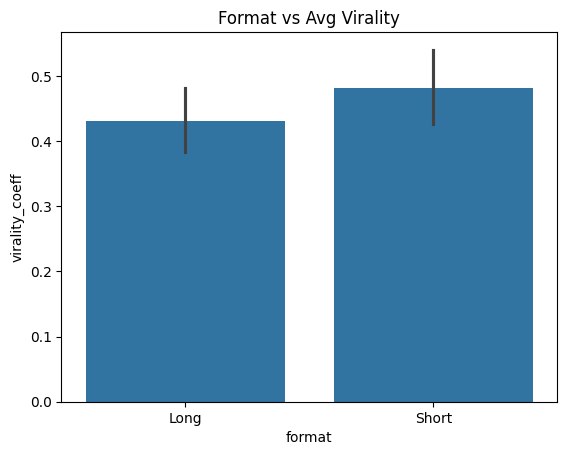

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Topic vs Virality
sns.barplot(data=df, x="topic", y="virality_coeff")
plt.title("Topic vs Avg Virality Score")
plt.xticks(rotation=45)
plt.savefig("charts/topic_virality.png")
plt.show()

# 2. Save-to-Share ratio
df["save_share_ratio"] = df["saves"] / (df["shares"] + 1)
sns.barplot(data=df, x="topic", y="save_share_ratio")
plt.title("Save-to-Share Ratio by Topic")
plt.xticks(rotation=45)
plt.savefig("charts/save_share.png")
plt.show()

# 3. Sentiment distribution
sentiment_counts = comments["sentiments"].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", colors=["blue","red"])
plt.title("Comment Sentiment Distribution")
plt.savefig("charts/sentiment_pie.png")
plt.show()

# 4. Format vs Virality
sns.barplot(data=df, x="format", y="virality_coeff")
plt.title("Format vs Avg Virality")
plt.savefig("charts/format_virality.png")
plt.show()

Printing the top 5 viral posts

In [120]:
top5 = df.nlargest(5, "virality_coeff")[["post_id","topic","format","virality_coeff"]]
print(top5)

    post_id             topic format  virality_coeff
68       69            Dating   Long           0.760
53       54  Self Improvement  Short           0.753
66       67     Mental Health   Long           0.716
65       66     Career Stress  Short           0.710
46       47            Dating  Short           0.680


Plotting a chart to predict the trend of rising virality in differnt topics
(the stats are not accurate, its only a demonstration)



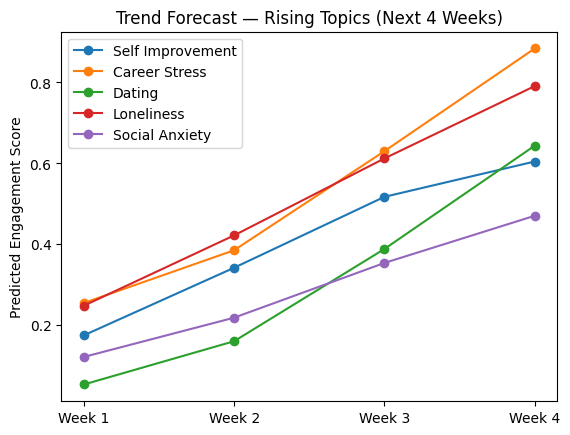

In [121]:
import numpy as np

weeks = ["Week 1", "Week 2", "Week 3", "Week 4"]
topics_trend = ["Self Improvement", "Career Stress", "Dating", "Loneliness", "Social Anxiety"]

np.random.seed(79)  

for topic in topics_trend:
    trend = np.cumsum(np.random.uniform(0.05, 0.3, 4)) 
    plt.plot(weeks, trend, marker="o", label=topic)

plt.title("Trend Forecast — Rising Topics (Next 4 Weeks)")
plt.ylabel("Predicted Engagement Score")
plt.legend()
plt.savefig("charts/trend_forecast.png")
plt.show()

Time for statistical modelling using Scikit learn library
training the model on 80% of dataset to derive retention rate from features like - "likes","shares". etc


In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

features = df[["likes", "shares", "saves", "comments"]]
target = df["retention_rate"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("R² Score:", round(r2_score(y_test, predictions), 3))
print("Model Coefficients:", dict(zip(features.columns, model.coef_.round(4))))

R² Score: 0.424
Model Coefficients: {'likes': np.float64(0.0001), 'shares': np.float64(0.0001), 'saves': np.float64(0.0), 'comments': np.float64(0.0001)}


                   likes    shares     saves  comments  retention_rate
likes           1.000000  0.778822  0.707019  0.701058        0.803025
shares          0.778822  1.000000  0.544463  0.604731        0.752584
saves           0.707019  0.544463  1.000000  0.648534        0.681276
comments        0.701058  0.604731  0.648534  1.000000        0.681536
retention_rate  0.803025  0.752584  0.681276  0.681536        1.000000


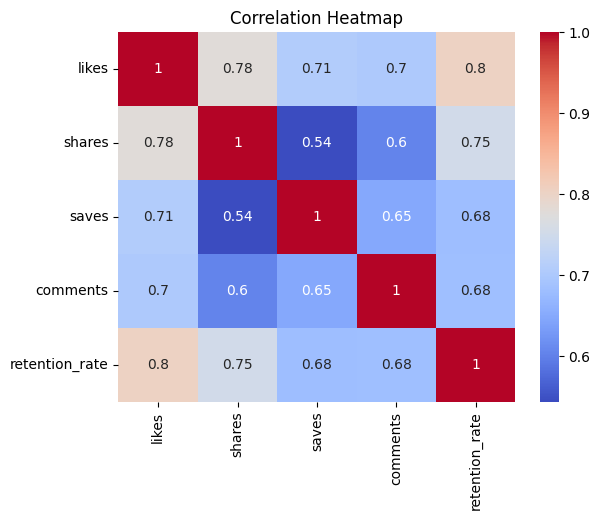

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df[['likes', 'shares', 'saves', 'comments', 'retention_rate']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

modifying the dataset to have it follow a linear pattern for satistical modelling
creating feature engagement_score and matching it with retention_rate

In [127]:
# Create weighted engagement score matching the generation formula
df['engagement_score'] = (0.7*df['saves'] + 0.5*df['shares'] + 0.2*df['comments'] + 0.1*df['likes']) / 1000

# Save to CSV with the new column
df.to_csv("data/content_performance.csv", index=False)

features = df[['engagement_score']]
target = df["retention_rate"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("R² Score:", round(r2_score(y_test, predictions), 3))

R² Score: 0.454
